# NeqSim safety source terms: from process models to external simulators

**A detailed, executable API tutorial for [NeqSim issue #3860](https://github.com/equinor/neqsim/issues/3860).**

Build current NeqSim **master**, solve process states, calculate model-explicit releases, and deliver
validated source terms to another program. This notebook covers steady processes, area-based
`ProcessModel` instances, native dynamics, coupled gas depletion, uncertainty, and live data handling.

The retained run uses master commit **`e4e9f27534870f510203512f912dd3aa2b9cde1d`** (21 September 2026).
The setup resolves `master` when run afresh; change `NEQSIM_SOURCE_REF` to that commit to reproduce
this source version. The outputs report the source and artifact actually loaded.

**Learning outcomes**

1. Select homogeneous-equilibrium, analytical ideal-gas, or explicit legacy-screening release physics.
2. Interpret upstream, throat, orifice-exit, and ambient-expanded states, including composition and phases.
3. Connect existing `ProcessSystem` / `ProcessModel` objects to steady and dynamic source frames.
4. Distinguish hypothetical sampling from component- and energy-conserving gas-inventory depletion.
5. Consume JSON/NDJSON through files, callbacks, an HTTP endpoint, and a separate Python process.
6. Reject stale, unsupported, incomplete, or reordered data and retain uncertainty failures.

All inputs are public synthetic teaching cases. The native contract labels its models **UNQUALIFIED**.
The examples establish API behavior, analytical limits, and conservation; they do not establish
facility qualification or solve atmospheric dispersion, fire, explosion, or toxic effects.

**Reader route:** Sections 1–4 establish the physical source; 5–9 connect a process and its dynamics;
10–12 implement the exchange and external consumer; 13–14 cover uncertainty and reusable exports.

## 1. Clean Colab setup and master-source provenance

Use a fresh CPU runtime. The first build can take several minutes. JPype starts one JVM per Python
process; restart the runtime before changing the Java artifact. The notebook deliberately loads the
source-built core directly rather than relying on the Java library bundled with a Python release.

Local validation can provide `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR`. A Git checkout must match
its recorded HEAD. A connector-reconstructed source snapshot additionally supplies
`NEQSIM_AUDITED_SOURCE_MANIFEST`: every source blob is verified against the recorded Git tree before
its artifact is accepted. No calculations are replaced with recorded outputs.

In [1]:
import importlib.util
import os
import subprocess
import sys

required = {
    "jpype": "jpype1",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "jsonschema": "jsonschema",
}
missing = [
    package for module, package in required.items() if importlib.util.find_spec(module) is None
]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
print("Python:", sys.version.split()[0])

Python: 3.12.14


In [2]:
import hashlib
import json
import shutil
import zipfile
from pathlib import Path

import jpype

NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
VALIDATED_COMMIT = "e4e9f27534870f510203512f912dd3aa2b9cde1d"
source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "neqsim-master-source")).resolve()
prebuilt_jar = os.environ.get("NEQSIM_SOURCE_JAR")


def command(arguments, cwd=None):
    return subprocess.check_output(arguments, cwd=cwd, text=True).strip()


if prebuilt_jar:
    source_jar = Path(prebuilt_jar).resolve()
    audit_path = os.environ.get("NEQSIM_AUDITED_SOURCE_MANIFEST")
    if audit_path:
        audit = json.loads(Path(audit_path).read_text())
        for relative, expected in audit["files"].items():
            file_path = source_root / relative
            data = file_path.read_bytes()
            header = f"blob {len(data)}\0".encode()
            assert hashlib.sha1(header + data).hexdigest() == expected, relative
        source_commit = audit["sha"]
        source_basis = "Full connector-tree blob verification"
    else:
        source_commit = command(["git", "rev-parse", "HEAD"], source_root)
        assert not command(
            ["git", "status", "--porcelain", "--untracked-files=no"], source_root
        )
        source_basis = "Clean Git checkout"
else:
    if not source_root.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/equinor/neqsim.git", str(source_root)],
            check=True,
        )
    subprocess.run(["git", "fetch", "origin", NEQSIM_SOURCE_REF], cwd=source_root, check=True)
    subprocess.run(["git", "checkout", "--detach", "FETCH_HEAD"], cwd=source_root, check=True)
    source_commit = command(["git", "rev-parse", "HEAD"], source_root)
    if shutil.which("javac") is None:
        subprocess.run(["apt-get", "-qq", "update"], check=True)
        subprocess.run(
            ["apt-get", "-qq", "install", "-y", "openjdk-17-jdk-headless"], check=True
        )
    subprocess.run(["chmod", "+x", str(source_root / "mvnw")], check=True)
    build_log = source_root / "safety-notebook-build.log"
    with build_log.open("w") as log:
        built = subprocess.run(
            [
                "./mvnw",
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "compile",
                "dependency:build-classpath",
                "-Dmdep.outputFile=target/runtime-classpath.txt",
            ],
            cwd=source_root,
            stdout=log,
            stderr=subprocess.STDOUT,
        )
    if built.returncode:
        print(build_log.read_text()[-12000:])
        raise RuntimeError("NeqSim source build failed; see retained build log")
    source_jar = source_root / "target/neqsim-safety-master.jar"
    with zipfile.ZipFile(source_jar, "w", zipfile.ZIP_DEFLATED) as archive:
        for file_path in sorted((source_root / "target/classes").rglob("*")):
            if file_path.is_file():
                archive.write(file_path, file_path.relative_to(source_root / "target/classes"))
    source_basis = "Fresh master/ref build"

classpath = (source_root / "target/runtime-classpath.txt").read_text().strip().split(os.pathsep)
assert source_jar.is_file()
assert len(source_commit) == 40
if jpype.isJVMStarted():
    raise RuntimeError("Restart the runtime so the intended NeqSim JAR is loaded first")
jpype.addClassPath(str(source_jar))
for dependency in classpath:
    jpype.addClassPath(dependency)
jpype.startJVM(convertStrings=True)
J = jpype.JClass
Inventory = J("neqsim.process.safety.release.ReleaseInventory")
loaded_from = str(Inventory.class_.getProtectionDomain().getCodeSource().getLocation())
from urllib.parse import unquote, urlparse

assert Path(unquote(urlparse(loaded_from).path)).resolve() == source_jar
provenance = {
    "source_repository": "https://github.com/equinor/neqsim",
    "requested_ref": NEQSIM_SOURCE_REF,
    "source_commit": source_commit,
    "source_basis": source_basis,
    "jar_sha256": hashlib.sha256(source_jar.read_bytes()).hexdigest(),
    "loaded_class_location": loaded_from,
    "java": str(J("java.lang.System").getProperty("java.version")),
    "python": sys.version.split()[0],
}
print(json.dumps(provenance, indent=2))

{
  "source_repository": "https://github.com/equinor/neqsim",
  "requested_ref": "master",
  "source_commit": "e4e9f27534870f510203512f912dd3aa2b9cde1d",
  "source_basis": "Full connector-tree blob verification",
  "jar_sha256": "3155bb426af80c22dada2dcef6afe8426bf7aed82253c809670b07608ffabe41",
  "loaded_class_location": "file:/workspace/scratch/14968d4bce5d/neqsim-master/target/neqsim-safety-master.jar",
  "java": "17.0.20",
  "python": "3.12.14"
}


## 2. API map and reusable helpers

NeqSim supplies the thermodynamics, release physics, process execution, and exchange contract. The
receiving application chooses its consequence model and maps the explicit station to its boundary.
Neither the schema nor a `VALID` calculation selects a dispersion method or establishes qualification.

| Layer | Native API | Responsibility |
|---|---|---|
| Process | `ProcessSystem`, `ProcessModel`, streams and equipment | Upstream state and native transient execution |
| Release physics | `ReleaseFlowRequest`, `ReleaseFlowModel`, `ReleaseFlowResult` | Geometry, selected model, checked stations and diagnostics |
| Physical depletion | `ReleaseInventory` | Component masses, internal energy, volume, and gas-only withdrawal |
| Live orchestration | `SourceTermSession` | Calculation identity, source binding, sequence, time, freshness, callbacks |
| Exchange | `SourceTermFrame` | JSON, NDJSON, reduced CSV, SI units and fingerprint |
| Uncertainty | `ReleaseFlowEnsemble` | Joint scenarios, original weights, failures and weighted statistics |
| External application | Reference receiver below | Schema, quality policy, sequence/age checks and boundary mapping |

In [3]:
from datetime import datetime, timedelta, timezone
from math import pi, sqrt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Code, Markdown, display
from jsonschema import Draft202012Validator

prefix = "neqsim.process.safety.release."
Request = J(prefix + "ReleaseFlowRequest")
HEM = J(prefix + "HomogeneousEquilibriumReleaseModel")
Ideal = J(prefix + "IdealGasReleaseModel")
Legacy = J(prefix + "LegacyScreeningReleaseModel")
Frame = J(prefix + "SourceTermFrame")
Session = J(prefix + "SourceTermSession")
Ensemble = J(prefix + "ReleaseFlowEnsemble")
EnsembleCase = J(prefix + "ReleaseFlowEnsemble$Case")
System = J("neqsim.thermo.system.SystemSrkEos")
Stream = J("neqsim.process.equipment.stream.Stream")
Process = J("neqsim.process.processmodel.ProcessSystem")
ProcessModel = J("neqsim.process.processmodel.ProcessModel")
UUID = J("java.util.UUID")
Instant = J("java.time.Instant")
Clock = J("java.time.Clock")
ZoneOffset = J("java.time.ZoneOffset")
HashMap = J("java.util.HashMap")
ArrayList = J("java.util.ArrayList")

# A fixed producer clock makes saved example frames reproducible, not live wall-clock evidence.
example_clock = Clock.fixed(Instant.parse("2026-09-21T12:00:00Z"), ZoneOffset.UTC)
example_instant = example_clock.instant()
replay_now = datetime(2026, 9, 21, 12, 0, 0, tzinfo=timezone.utc)
export_dir = Path("safety_source_term_results")
export_dir.mkdir(exist_ok=True)
with zipfile.ZipFile(source_jar) as archive:
    schema = json.loads(
        archive.read("neqsim/process/safety/release/schema/safety-source-term.schema.json")
    )
validator = Draft202012Validator(schema)
(export_dir / "safety-source-term.schema.json").write_text(json.dumps(schema, indent=2))
all_frames = []
checks = {}
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 160)
plt.rcParams.update(
    {
        "figure.figsize": (11, 4.5),
        "figure.dpi": 125,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
        "font.size": 10,
        "axes.titlesize": 13,
    }
)


def fluid(components, temperature_K=300.0, pressure_bara=5.0):
    assert abs(sum(components.values()) - 1.0) < 1e-12
    result = System(temperature_K, pressure_bara)
    for name, fraction in components.items():
        result.addComponent(name, fraction)
    result.setMixingRule("classic")
    return result


def java_map(values):
    result = HashMap()
    for key, value in values.items():
        result.put(key, value)
    return result


def parsed(frame):
    raw = str(frame.toJson())
    Frame.verifyEnvelope(raw)
    result = json.loads(raw)
    validator.validate(result)
    all_frames.append(raw)
    return result


def frame_from_result(request, result, source_id="opening", sequence=0):
    return Frame.calculated(
        "direct-api",
        source_id,
        UUID.fromString("00000000-0000-0000-0000-000000003860"),
        sequence,
        0.0,
        example_instant,
        request,
        result,
        java_map({"neqsimCommit": source_commit, "inputBasis": "synthetic teaching case"}),
    )


def value(quantity):
    return float(quantity["value"])


def stations_table(frame_data):
    records = []
    for name, state in frame_data["source"]["stations"].items():
        records.append(
            {
                "Station": name,
                "Pressure [bara]": value(state["pressure"]) / 1e5,
                "Temperature [K]": value(state["temperature"]),
                "Density [kg/m3]": value(state["density"]),
                "Velocity [m/s]": value(state["velocity"]),
                "Gas mass fraction [-]": state["phaseMassFractions"].get("GAS", 0.0),
            }
        )
    return pd.DataFrame(records).set_index("Station")


def frame_row(frame):
    data = parsed(frame)
    row = {
        "source": data["sourceId"],
        "sequence": data["sequence"],
        "time_s": value(data["simulationTime"]),
        "status": data["status"],
        "release_basis": data["provenance"].get("releaseBasis", "DIRECT_REQUEST"),
    }
    if "source" in data:
        upstream = data["source"]["stations"]["UPSTREAM_STAGNATION"]
        row.update(
            {
                "rate_kg_s": value(data["source"]["massFlowRate"]),
                "pressure_bara": value(upstream["pressure"]) / 1e5,
                "temperature_K": value(upstream["temperature"]),
            }
        )
    return row


print("Native source-term schema loaded from the tested JAR:", Frame.SCHEMA_VERSION)

Native source-term schema loaded from the tested JAR: neqsim_safety_source_term.v1


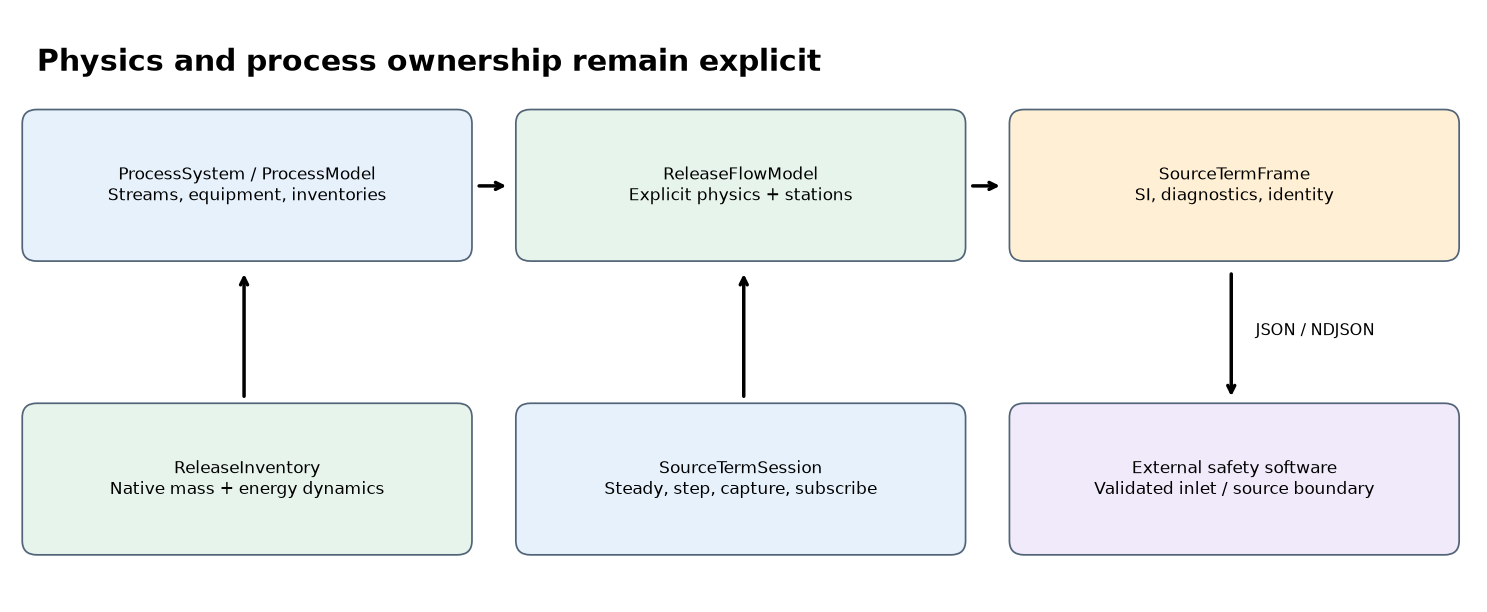

In [4]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 5))
ax.set(xlim=(0, 12), ylim=(0, 5))
ax.axis("off")
boxes = [
    (0.2, 3.0, "ProcessSystem / ProcessModel\nStreams, equipment, inventories", "#e6f1fb"),
    (4.25, 3.0, "ReleaseFlowModel\nExplicit physics + stations", "#e7f4eb"),
    (8.3, 3.0, "SourceTermFrame\nSI, diagnostics, identity", "#fff0d5"),
    (0.2, 0.5, "ReleaseInventory\nNative mass + energy dynamics", "#e7f4eb"),
    (4.25, 0.5, "SourceTermSession\nSteady, step, capture, subscribe", "#e6f1fb"),
    (8.3, 0.5, "External safety software\nValidated inlet / source boundary", "#f0eafa"),
]
for x, y, label, color in boxes:
    ax.add_patch(
        FancyBboxPatch(
            (x, y),
            3.45,
            1.05,
            boxstyle="round,pad=0.12",
            facecolor=color,
            edgecolor="#526477",
        )
    )
    ax.text(x + 1.725, y + 0.525, label, ha="center", va="center", fontsize=10)
for start, finish in [
    ((3.8, 3.52), (4.08, 3.52)),
    ((7.85, 3.52), (8.13, 3.52)),
    ((1.9, 1.7), (1.9, 2.8)),
    ((6.0, 1.7), (6.0, 2.8)),
    ((10.0, 2.8), (10.0, 1.7)),
]:
    ax.annotate("", xy=finish, xytext=start, arrowprops={"arrowstyle": "->", "lw": 2})
ax.text(10.2, 2.25, "JSON / NDJSON", fontsize=9)
ax.text(0.2, 4.5, "Physics and process ownership remain explicit", fontsize=17, weight="bold")
fig.tight_layout()
plt.show()

## 3. Release physics and the thermodynamic stations

The upstream state is stagnation pressure and temperature. For the homogeneous-equilibrium model,
NeqSim solves the equilibrium state at constant specific entropy, then searches the pressure path
for maximum mass flux:

$$u(p)=\sqrt{2\left[h_0-h(p,s_0)\right]},\qquad G(p)=\rho(p,s_0)u(p).$$

$$\dot m=C_d A\max_{p_b\leq p\leq p_0}G(p),\qquad A=\frac{\pi d^2}{4}.$$

Here $u$ is velocity [m/s], $h$ specific enthalpy [J/kg], $s$ specific entropy [J/(kg K)],
$\rho$ density [kg/m3], $G$ mass flux [kg/(m2 s)], $C_d$ discharge coefficient [-],
$d$ physical opening diameter [m], and $p_b$ receiving pressure [Pa absolute].

| Station | Meaning for a short opening | How a consumer should interpret it |
|---|---|---|
| `UPSTREAM_STAGNATION` | Reservoir state, zero velocity | Process state and outgoing stagnation enthalpy |
| `THROAT_CRITICAL` | Accepted maximum-flux state, or receiving-pressure state when unchoked | Choking and critical-state diagnostics |
| `ORIFICE_EXIT` | Same state as throat for the zero-length opening | A pressure-resolving jet/nozzle boundary |
| `AMBIENT_EXPANDED` | Ideal isentropic state at receiving pressure | An expansion reference; shocks and entrainment are absent |

The ideal-gas adapter uses constant upstream $\gamma$ and NeqSim molar mass; the HEM uses EOS flashes.
The legacy adapter reproduces the historical scalar rate but reports unresolved stations and
`SCREENING_ONLY`. It is unsuitable for the checked spatial boundary mapping later in this notebook.

In [5]:
gas = fluid({"methane": 1.0})
request = Request(gas, 0.010, 0.62, 101325.0)
models = {"HEM": HEM(), "Ideal gas": Ideal(), "Legacy screening": Legacy()}
model_results = {}
model_frames = {}
comparison = []
for name, model in models.items():
    result = model.calculate(request)
    assert result.isUsable(), str(result.getDiagnostics())
    data = parsed(frame_from_result(request, result, name))
    model_results[name] = result
    model_frames[name] = data
    comparison.append(
        {
            "Model": name,
            "Status": data["status"],
            "Rate [kg/s]": value(data["source"]["massFlowRate"]),
            "Choked": data["source"]["choked"],
            "Diagnostics": ", ".join(item["code"] for item in data["diagnostics"]),
        }
    )
display(pd.DataFrame(comparison).set_index("Model"))
display(stations_table(model_frames["HEM"]).round(6))
assert all(
    state["phaseMassFractions"]["GAS"] > 0.999999
    for state in model_frames["HEM"]["source"]["stations"].values()
)

,Status,Rate [kg/s],Choked,Diagnostics
Model,,,,
HEM,VALID,0.041526,True,"MODEL_ASSUMPTIONS, EXIT_ALIASES_THROAT, ENTROPY_SOLVER"
Ideal gas,VALID,0.041381,True,"IDEAL_GAS_ASSUMPTIONS, NO_PROPERTY_FALLBACK, EXIT_ALIASES_THROAT"
Legacy screening,VALID_WITH_WARNINGS,0.041321,True,"SCREENING_ONLY, UNRESOLVED_STATIONS, LEGACY_FALLBACK_POLICY"


,Pressure [bara],Temperature [K],Density [kg/m3],Velocity [m/s],Gas mass fraction [-]
Station,,,,,
AMBIENT_EXPANDED,1.013250,202.837627,0.969964,639.296946,1.0
ORIFICE_EXIT,2.709346,259.092691,2.033398,419.387194,1.0
THROAT_CRITICAL,2.709346,259.092691,2.033398,419.387194,1.0
UPSTREAM_STAGNATION,5.000000,300.000000,3.242662,0.000000,1.0


In [6]:
hem_data = model_frames["HEM"]
upstream = hem_data["source"]["stations"]["UPSTREAM_STAGNATION"]
closure_rows = []
for station_name, station in hem_data["source"]["stations"].items():
    velocity = value(station["velocity"])
    energy_residual = (
        value(station["specificEnthalpy"])
        + velocity**2 / 2.0
        - value(upstream["specificEnthalpy"])
    )
    entropy_residual = value(station["specificEntropy"]) - value(upstream["specificEntropy"])
    phase_sum = sum(station["phaseMassFractions"].values())
    assert abs(energy_residual) < 1e-4
    assert abs(entropy_residual) < 1e-5
    assert abs(phase_sum - 1.0) < 1e-8
    closure_rows.append(
        {
            "Station": station_name,
            "Energy residual [J/kg]": energy_residual,
            "Entropy residual [J/(kg K)]": entropy_residual,
            "Phase mass sum [-]": phase_sum,
        }
    )
checks["station_energy_entropy_phase_closure"] = True
display(pd.DataFrame(closure_rows).set_index("Station"))

,Energy residual [J/kg],Entropy residual [J/(kg K)],Phase mass sum [-]
Station,,,
AMBIENT_EXPANDED,-2.910383e-11,-2.119028e-07,1.0
ORIFICE_EXIT,-7.275958e-12,-6.227475e-07,1.0
THROAT_CRITICAL,-7.275958e-12,-6.227475e-07,1.0
UPSTREAM_STAGNATION,0.000000e+00,0.000000e+00,1.0


### An independent discharge equation and the choking transition

For a constant-$\gamma$ ideal gas, use the upstream NeqSim properties but calculate the rate
independently in Python. This validates the discharge equation, **not independent property data**.

$$r_c=\left(\frac{2}{\gamma+1}\right)^{\gamma/(\gamma-1)},\qquad r=\max(p_b/p_0,r_c).$$

$$\dot m=C_d A p_0\sqrt{\frac{2\gamma}{R_sT_0(\gamma-1)}\left(r^{2/\gamma}-r^{(\gamma+1)/\gamma}\right)}.$$

$R_s=R/M$ [J/(kg K)], $R=8.31446261815324$ [J/(mol K)], $M$ molar mass [kg/mol],
and $\gamma=c_p/c_v$ [-]. The low upstream pressure below is an analytical-limit test, with all
receiving pressures also low; it is not an atmospheric-release operating case.

,Backpressure ratio [-],HEM [kg/s],Independent equation [kg/s],Relative difference [%],Choked
0,0.05,0.000827,0.000825,0.260385,True
1,0.20,0.000827,0.000825,0.260385,True
2,0.40,0.000827,0.000825,0.260385,True
3,0.50,0.000827,0.000825,0.260385,True
4,0.55,0.000827,0.000824,0.251234,False
5,0.70,0.000778,0.000777,0.096097,False
6,0.90,0.000520,0.000520,0.015496,False
7,0.98,0.000244,0.000244,0.008427,False


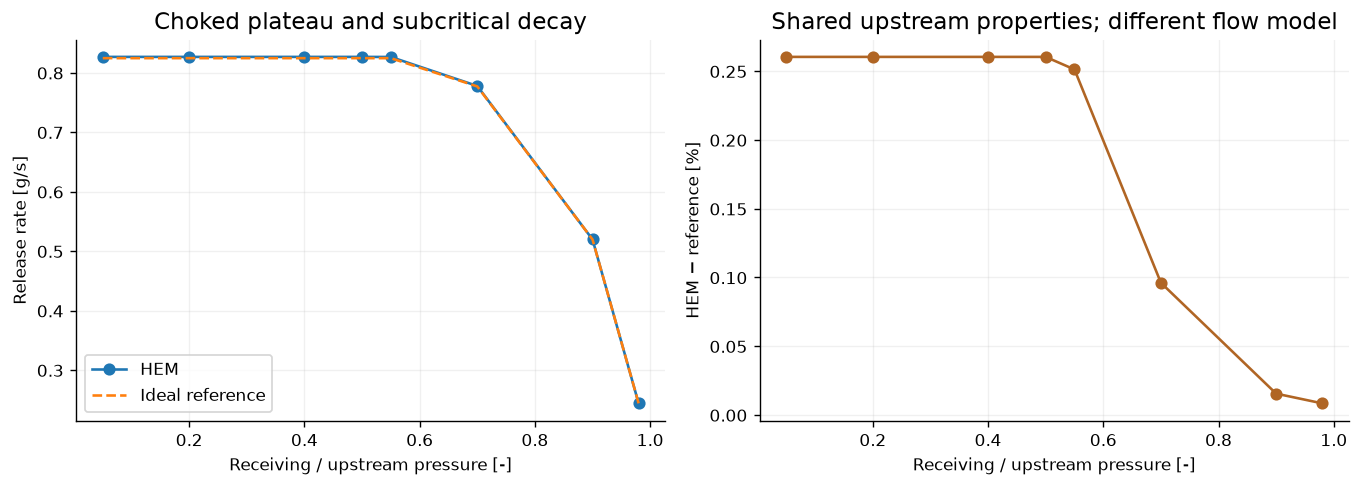

In [7]:
def ideal_reference(test_fluid, diameter_m, coefficient, receiving_Pa):
    initialized = test_fluid.clone()
    J("neqsim.thermodynamicoperations.ThermodynamicOperations")(initialized).TPflash()
    initialized.init(3)
    pressure_Pa = initialized.getPressure("Pa")
    if receiving_Pa >= pressure_Pa:
        return 0.0
    gamma = initialized.getGamma()
    gas_constant = 8.31446261815324 / initialized.getMolarMass()
    critical_ratio = (2.0 / (gamma + 1.0)) ** (gamma / (gamma - 1.0))
    ratio = max(receiving_Pa / pressure_Pa, critical_ratio)
    factor = 2.0 * gamma / (gas_constant * initialized.getTemperature() * (gamma - 1.0))
    expansion = ratio ** (2.0 / gamma) - ratio ** ((gamma + 1.0) / gamma)
    return coefficient * pi * diameter_m**2 / 4.0 * pressure_Pa * sqrt(factor * expansion)


benchmark_gas = fluid({"methane": 1.0}, pressure_bara=0.1)
benchmark_rows = []
for ratio in [0.05, 0.20, 0.40, 0.50, 0.55, 0.70, 0.90, 0.98]:
    backpressure = ratio * 1e4
    case_request = Request(benchmark_gas, 0.01, 0.62, backpressure)
    result = HEM().calculate(case_request)
    assert result.isUsable()
    analytical = ideal_reference(benchmark_gas, 0.01, 0.62, backpressure)
    relative_error = result.getMassFlowRateKgS() / analytical - 1.0
    assert abs(relative_error) < 0.015
    benchmark_rows.append(
        {
            "Backpressure ratio [-]": ratio,
            "HEM [kg/s]": result.getMassFlowRateKgS(),
            "Independent equation [kg/s]": analytical,
            "Relative difference [%]": 100 * relative_error,
            "Choked": bool(result.isChoked()),
        }
    )
benchmark = pd.DataFrame(benchmark_rows)
checks["dilute_gas_reference_within_1_5_percent"] = True
display(benchmark)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(benchmark.iloc[:, 0], benchmark.iloc[:, 1] * 1000, "o-", label="HEM")
axes[0].plot(benchmark.iloc[:, 0], benchmark.iloc[:, 2] * 1000, "--", label="Ideal reference")
axes[0].set(
    xlabel="Receiving / upstream pressure [-]",
    ylabel="Release rate [g/s]",
    title="Choked plateau and subcritical decay",
)
axes[0].legend()
axes[1].plot(benchmark.iloc[:, 0], benchmark.iloc[:, 3], "o-", color="#b06524")
axes[1].set(
    xlabel="Receiving / upstream pressure [-]",
    ylabel="HEM − reference [%]",
    title="Shared upstream properties; different flow model",
)
fig.tight_layout()
plt.show()

## 4. Flashing, dense fluid, and explicit applicability failures

A flashing propane example exposes phase **mass** fractions along the expansion. Dense CO2 at high
backpressure exercises an EOS state without claiming experimental accuracy of its release rate.
A cold CO2 case and a documented unresolved multicomponent flash demonstrate fail-closed behavior.
No substitute flow, automatic ideal-gas fallback, or last valid result is inserted.

In [8]:
regime_cases = [
    ("Flashing propane", {"propane": 1.0}, 300.0, 20.0, 3e5),
    ("Dense CO2 / high backpressure", {"CO2": 1.0}, 310.0, 120.0, 110e5),
    ("CO2 / solid-risk boundary", {"CO2": 1.0}, 210.0, 20.0, 1e5),
    ("Unresolved flashing mixture", {"propane": 0.8, "n-butane": 0.2}, 300.0, 20.0, 3e5),
]
regime_rows = []
regime_frames = {}
for index, (name, composition, temperature, pressure, receiving) in enumerate(regime_cases):
    case_request = Request(fluid(composition, temperature, pressure), 0.01, 0.62, receiving)
    result = HEM().calculate(case_request)
    data = parsed(frame_from_result(case_request, result, name, index))
    regime_frames[name] = data
    regime_rows.append(
        {
            "Case": name,
            "Status": data["status"],
            "Numeric source present": "source" in data,
            "Rate [kg/s]": (
                value(data["source"]["massFlowRate"]) if "source" in data else np.nan
            ),
            "Diagnostic codes": ", ".join(item["code"] for item in data["diagnostics"]),
        }
    )
    if not result.isUsable():
        assert "source" not in data
        try:
            result.getMassFlowRateKgS()
        except Exception:
            pass
        else:
            raise AssertionError("An unusable result exposed a numeric rate")
display(pd.DataFrame(regime_rows).set_index("Case"))
display(stations_table(regime_frames["Flashing propane"]).round(5))
propane_stations = regime_frames["Flashing propane"]["source"]["stations"]
assert 0.0 < propane_stations["AMBIENT_EXPANDED"]["phaseMassFractions"]["GAS"] < 1.0
for case_name, data in regime_frames.items():
    display(Markdown("**" + case_name + " — native diagnostics**"))
    display(pd.DataFrame(data["diagnostics"]))
checks["unavailable_rates_not_zero_filled"] = True

,Status,Numeric source present,Rate [kg/s],Diagnostic codes
Case,,,,
Flashing propane,VALID_WITH_WARNINGS,True,1.470075,"MODEL_ASSUMPTIONS, EXIT_ALIASES_THROAT, ENTROPY_SOLVER, THROAT_MACH_MISMATCH"
Dense CO2 / high backpressure,VALID,True,1.724142,"MODEL_ASSUMPTIONS, EXIT_ALIASES_THROAT, ENTROPY_SOLVER"
CO2 / solid-risk boundary,UNSUPPORTED,False,NaN,UNSUPPORTED_PHYSICS
Unresolved flashing mixture,INVALID,False,NaN,CALCULATION_FAILED


,Pressure [bara],Temperature [K],Density [kg/m3],Velocity [m/s],Gas mass fraction [-]
Station,,,,,
AMBIENT_EXPANDED,3.00000,258.97225,26.13498,149.85558,0.24372
ORIFICE_EXIT,9.83255,298.98657,449.85462,67.10976,0.00000
THROAT_CRITICAL,9.83255,298.98657,449.85462,67.10976,0.00000
UPSTREAM_STAGNATION,20.00000,300.00000,453.14963,0.00000,0.00000


**Flashing propane — native diagnostics**

,code,message
0,MODEL_ASSUMPTIONS,"Equilibrium, zero slip, isentropic acceleration; no pipe friction, heat transfer or solids"
1,EXIT_ALIASES_THROAT,Zero-length opening: exit equals accepted throat
2,ENTROPY_SOLVER,Pure-fluid PS flash retains saturation quality
3,THROAT_MACH_MISMATCH,Equilibrium Mach=0.1222764825033262; phase-boundary maximum may be nonsmooth


**Dense CO2 / high backpressure — native diagnostics**

,code,message
0,MODEL_ASSUMPTIONS,"Equilibrium, zero slip, isentropic acceleration; no pipe friction, heat transfer or solids"
1,EXIT_ALIASES_THROAT,Zero-length opening: exit equals accepted throat
2,ENTROPY_SOLVER,Pure-fluid PS flash retains saturation quality


**CO2 / solid-risk boundary — native diagnostics**

,code,message
0,UNSUPPORTED_PHYSICS,CO2 below 216.592 K requires a separately assessed solid-capable model


**Unresolved flashing mixture — native diagnostics**

,code,message
0,CALCULATION_FAILED,Mixture entropy root did not converge at 823118.4346510068 Pa


The gas fraction can rise dramatically between reservoir and ambient-expanded conditions. A receiver
must choose the appropriate station and phase representation; using the upstream liquid density as
the expanded-cloud density would discard the flash result. The HEM assumes equilibrium and zero slip.
Droplet size, delayed flashing, rainout, shocks, entrainment, and solid transport need additional models.
The unresolved mixture case remains part of [#3860](https://github.com/equinor/neqsim/issues/3860).

In the retained propane result, `THROAT_MACH_MISMATCH` reports an equilibrium Mach number of
about 0.122 at a phase-boundary maximum. This is a material acoustic warning, not a verified smooth
sonic throat. The rate is retained for inspection with `VALID_WITH_WARNINGS`; the strict example
receiver rejects that unreviewed diagnostic. The dense-CO2 result establishes a resolved EOS
calculation, not independent accuracy of the predicted rate.

## 5. A steady process: register sources on existing equipment

The synthetic gas train contains a feed, cooler, pressure-reducing valve, and separator. We sample
openings before and after the pressure reduction, and explicitly select the separator gas outlet.
All pressure inputs labelled `bara` are absolute. Feed flow is a process throughput; the hypothetical
opening rate is a separate calculation and is not subtracted from that throughput.

In [9]:
Heater = J("neqsim.process.equipment.heatexchanger.Heater")
Valve = J("neqsim.process.equipment.valve.ThrottlingValve")
Separator = J("neqsim.process.equipment.separator.Separator")
feed = Stream("feed", fluid({"methane": 0.95, "ethane": 0.05}, 315.0, 5.0))
feed.setFlowRate(100.0, "kg/hr")
cooler = Heater("cooler", feed)
cooler.setOutTemperature(300.0)
valve = Valve("letdown", cooler.getOutletStream())
valve.setOutletPressure(3.0)
separator = Separator("separator", valve.getOutletStream())
process = Process()
for unit in [feed, cooler, valve, separator]:
    process.add(unit)
steady_session = Session("steady-gas-train", process, example_clock)
steady_session.addSource("feed-opening", "feed", 0.01, 0.62, 101325.0, HEM())
steady_session.addSource("valve-outlet", "letdown", 0.01, 0.62, 101325.0, HEM())
steady_session.addSource(
    "separator-gas",
    Session.SINGLE_AREA,
    "separator",
    0,
    0.01,
    0.62,
    101325.0,
    HEM(),
)
steady_frames = list(steady_session.runSteadyState())
steady_table = pd.DataFrame([frame_row(frame) for frame in steady_frames])
display(steady_table.drop(columns="release_basis"))
output_rate = separator.getGasOutStream().getFlowRate(
    "kg/hr"
) + separator.getLiquidOutStream().getFlowRate("kg/hr")
assert abs(output_rate / feed.getFlowRate("kg/hr") - 1.0) < 1e-7
assert all("HYPOTHETICAL" in item for item in steady_table["release_basis"])
checks["steady_process_mass_balance"] = True
print("Feed and total products [kg/hr]:", feed.getFlowRate("kg/hr"), output_rate)

Feed and total products [kg/hr]: 100.0 100.0


,source,sequence,time_s,status,rate_kg_s,pressure_bara,temperature_K
0,feed-opening,0,0.0,VALID,0.041218,5.0,315.000000
1,valve-outlet,1,0.0,VALID,0.025396,3.0,299.032668
2,separator-gas,2,0.0,VALID,0.025396,3.0,299.032668


## 6. External ownership: solve first, then capture with the actual calculation UUID

An external digital-twin service may own the process solve. It changes inputs, runs the process,
and supplies the UUID of that successful solve to `capture`. Supplying an old UUID after a failure
is not recovery. Serialize all process access, including changes through references outside the session.

In [10]:
live_feed = Stream("feed", fluid({"methane": 0.95, "ethane": 0.05}))
live_feed.setFlowRate(100.0, "kg/hr")
live_process = Process()
live_process.add(live_feed)
live_session = Session("externally-owned", live_process, example_clock)
live_session.addSource("opening", "feed", 0.01, 0.62, 101325.0, HEM())
live_initial = live_session.runSteadyState().get(0)
external_id = UUID.randomUUID()
live_feed.setPressure(4.5, "bara")
live_process.run(external_id)
current = live_session.capture(java_map({str(Session.SINGLE_AREA): external_id})).get(0)
wrong_id = UUID.randomUUID()
stale = live_session.capture(java_map({str(Session.SINGLE_AREA): wrong_id})).get(0)
stale_data = parsed(stale)
assert stale_data["status"] == "STALE" and "source" not in stale_data
restored = live_session.capture(java_map({str(Session.SINGLE_AREA): external_id})).get(0)
live_session.setEnabled("opening", False)
disabled = live_session.capture(java_map({str(Session.SINGLE_AREA): external_id})).get(0)
display(
    pd.DataFrame(
        [frame_row(frame) for frame in [live_initial, current, stale, restored, disabled]]
    )
)
print("STALE diagnostics:", stale_data["diagnostics"])
checks["stale_capture_omits_numeric_payload"] = True

STALE diagnostics: [{'code': 'PROCESS_STATE_STALE', 'message': 'Area not solved with expected calculation UUID: process'}]


,source,sequence,time_s,status,release_basis,rate_kg_s,pressure_bara,temperature_K
0,opening,0,0.0,VALID,HYPOTHETICAL_OPENING_NO_INVENTORY_FEEDBACK,0.042340,5.0,300.0
1,opening,1,0.0,VALID,HYPOTHETICAL_OPENING_NO_INVENTORY_FEEDBACK,0.038086,4.5,300.0
2,opening,2,0.0,STALE,HYPOTHETICAL_OPENING_NO_INVENTORY_FEEDBACK,NaN,NaN,NaN
3,opening,3,0.0,VALID,HYPOTHETICAL_OPENING_NO_INVENTORY_FEEDBACK,0.038086,4.5,300.0
4,opening,4,0.0,DISABLED,HYPOTHETICAL_OPENING_NO_INVENTORY_FEEDBACK,NaN,NaN,NaN


## 7. ProcessModel: area identity, changing composition, and native vessel dynamics

Area-qualified registration prevents ambiguous equipment names. `step(dt)` calls native process
dynamics; it does not make every equipment model dynamic. First we change feed composition between
steps. Then a separate separator example activates its native volume/internal-energy state and adds
heat. Its initial liquid level is explicitly zero for a gas-only inventory. Both examples retain a hypothetical opening, so that opening has no inventory feedback.

In [11]:
area_model = ProcessModel()
area_feeds = {}
for area_name, pressure in [("train-a", 5.0), ("train-b", 4.0)]:
    area = Process()
    inlet = Stream("feed", fluid({"methane": 0.95, "ethane": 0.05}, 300.0, pressure))
    inlet.setFlowRate(100.0, "kg/hr")
    area.add(inlet)
    area_model.add(area_name, area)
    area_feeds[area_name] = inlet
area_session = Session("two-train-facility", area_model, example_clock)
for area_name in area_feeds:
    area_session.addSource(
        area_name + "-opening", area_name, "feed", -1, 0.01, 0.62, 101325.0, HEM()
    )
area_frames = list(area_session.runSteadyState())
assert area_model.isModelConverged()
area_feeds["train-a"].getFluid().setMolarComposition([0.8, 0.2])
area_feeds["train-a"].setTemperature(320.0, "K")
area_frames.extend(list(area_session.step(0.25)))
area_rows = []
for frame in area_frames:
    data = parsed(frame)
    upstream_state = data["source"]["stations"]["UPSTREAM_STAGNATION"]
    area_rows.append(
        {
            "Area": data["provenance"]["area"],
            "Sequence": data["sequence"],
            "Time [s]": value(data["simulationTime"]),
            "Ethane mole fraction [-]": upstream_state["componentMoleFractions"]["ethane"],
            "Rate [kg/s]": value(data["source"]["massFlowRate"]),
            "Area calculation UUID": data["provenance"]["areaCalculationId"],
        }
    )
assert abs(area_rows[2]["Ethane mole fraction [-]"] - 0.2) < 1e-10
display(pd.DataFrame(area_rows))
checks["process_model_composition_and_identity"] = True

,Area,Sequence,Time [s],Ethane mole fraction [-],Rate [kg/s],Area calculation UUID
0,train-a,0,0.00,0.05,0.042340,9dfda172-ff40-4d47-b2ee-0e2db56d9d4b
1,train-b,1,0.00,0.05,0.033837,249f023f-57d3-4ce8-84fe-78da8d635414
2,train-a,2,0.25,0.20,0.043101,b96b8c87-b967-4f73-bb59-5f31d450e74d
3,train-b,3,0.25,0.05,0.033837,b96b8c87-b967-4f73-bb59-5f31d450e74d


In [12]:
dynamic_feed = Stream("feed", fluid({"methane": 0.95, "ethane": 0.05}))
dynamic_feed.setFlowRate(10.0, "kg/hr")
dynamic_separator = Separator("vessel", dynamic_feed)
dynamic_separator.setInternalDiameter(1.0)
dynamic_separator.setSeparatorLength(2.0)
# Gas-only inventory: do not initialize an artificial liquid-filled half-volume.
dynamic_separator.setLiquidLevel(0.0)
dynamic_process = Process()
dynamic_process.add(dynamic_feed)
dynamic_process.add(dynamic_separator)
dynamic_session = Session("heated-separator", dynamic_process, example_clock)
dynamic_session.addSource("vessel-opening", "vessel", 0.005, 0.62, 101325.0, HEM())
separator_initial = dynamic_session.runSteadyState().get(0)
dynamic_separator.setCalculateSteadyState(False)
dynamic_separator.setHeatInput(2.0, "kW")
separator_next = dynamic_session.step(0.1).get(0)
separator_rows = pd.DataFrame([frame_row(separator_initial), frame_row(separator_next)])
assert separator_rows.iloc[1]["temperature_K"] > separator_rows.iloc[0]["temperature_K"]
assert (
    abs(separator_rows.iloc[1]["temperature_K"] - dynamic_separator.getFluid().getTemperature())
    < 1e-5
)
display(separator_rows.drop(columns="release_basis"))
checks["native_separator_dynamics_reach_frames"] = True

,source,sequence,time_s,status,rate_kg_s,pressure_bara,temperature_K
0,vessel-opening,0,0.0,VALID,0.010585,5.000000,300.000000
1,vessel-opening,1,0.1,VALID,0.010585,5.000374,300.021971


## 8. Coupled gas blowdown: release changes the next upstream state

`ReleaseInventory` owns a fixed-volume, adiabatic, well-mixed gas inventory. Its constructor scales
composition to the specified vessel volume. Its native transient step removes component mass and
**stagnation enthalpy**, solves a VU flash, and checks volume and energy closure.

$$\frac{dm_i}{dt}=-w_i\dot m,\qquad \frac{dU}{dt}=-h_0\dot m,\qquad V=\mathrm{constant}.$$

Here $m_i$ is component mass [kg], $w_i$ its mass fraction [-], $U$ inventory internal energy [J],
and $h_0$ upstream stagnation enthalpy [J/kg]. Removing internal energy per kilogram instead of
enthalpy would omit flow work and predict incorrect cooling. Signed energies retain the EOS reference.

The main trajectory uses nitrogen at 5 bara and 300 K, volume 1 m3, a 10 mm opening, $C_d=0.7$,
and receiving pressure 1.01325 bara. The analytical model is explicitly selected for a fast teaching
trajectory. A short multicomponent HEM case then exercises EOS-based coupled release.

At 6 s we **close the physical opening** using `setReleaseEnabled(False)`. This represents closure
of that opening, not merely closure of an upstream isolation valve: trapped gas can continue to leak
after upstream isolation. The event is placed exactly on a step boundary.

In [13]:
def inventory_system(scenario, use_model=False, max_substep_s=0.05, initial_bara=5.0):
    vessel = Inventory(
        "inventory",
        fluid({"nitrogen": 1.0}, 300.0, initial_bara),
        1.0,
        0.01,
        0.7,
        101325.0,
        Ideal(),
        max_substep_s,
    )
    unit_process = Process()
    unit_process.add(vessel)
    if use_model:
        model = ProcessModel()
        model.add("gas-area", unit_process)
        session = Session(scenario, model, example_clock)
        session.addInventorySource("opening", "gas-area", "inventory")
    else:
        session = Session(scenario, unit_process, example_clock)
        session.addInventorySource("opening", "inventory")
    return vessel, session


def balance_row(vessel):
    balance = vessel.getBalance()
    initial_mass = sum(float(v) for v in balance.getInitialComponentMassKg().values())
    remaining_mass = sum(float(v) for v in balance.getRemainingComponentMassKg().values())
    released_mass = balance.getReleasedMassKg()
    return {
        "time_s": balance.getTimeS(),
        "initial_mass_kg": initial_mass,
        "remaining_mass_kg": remaining_mass,
        "released_mass_kg": released_mass,
        "mass_residual_kg": initial_mass - remaining_mass - released_mass,
        "energy_residual_J": (
            balance.getInitialEnergyJ()
            - balance.getInternalEnergyJ()
            - balance.getReleasedEnergyJ()
        ),
        "temperature_K": vessel.getFluid().getTemperature(),
        "pressure_bara": vessel.getFluid().getPressure(),
        "last_substeps": balance.getSubsteps(),
        "last_VU_solves": vessel.getLastVolumeEnergySolves(),
    }


vessel, inventory_session = inventory_system("coupled-gas-inventory")
inventory_frames = list(inventory_session.runSteadyState())
inventory_balances = [balance_row(vessel)]
for step_index in range(1, 17):
    if step_index == 13:
        vessel.setReleaseEnabled(False)
    inventory_frames.extend(list(inventory_session.step(0.5)))
    inventory_balances.append(balance_row(vessel))
trajectory = pd.DataFrame([frame_row(frame) for frame in inventory_frames])
balances = pd.DataFrame(inventory_balances)
assert balances["mass_residual_kg"].abs().max() < 1e-7
assert balances["energy_residual_J"].abs().max() < 0.01
assert balances.iloc[-1]["released_mass_kg"] == balances.iloc[12]["released_mass_kg"]
assert trajectory.iloc[-1]["status"] == "DISABLED"
checks["coupled_inventory_mass_energy_and_closure_event"] = True
display(balances.iloc[[0, 4, 8, 12, 16]].round(8))
display(trajectory[["time_s", "status", "rate_kg_s"]].tail(6))

,time_s,initial_mass_kg,remaining_mass_kg,released_mass_kg,mass_residual_kg,energy_residual_J,temperature_K,pressure_bara,last_substeps,last_VU_solves
0,0.0,5.616049,5.616049,0.000000,0.0,0.000000,300.000000,5.000000,0,0
4,2.0,5.616049,5.491279,0.124771,0.0,-0.000070,297.289425,4.844228,11,161
8,4.0,5.616049,5.369838,0.246212,-0.0,-0.000137,294.615662,4.694009,11,161
12,6.0,5.616049,5.251622,0.364427,-0.0,-0.000202,291.978051,4.549122,11,161
16,8.0,5.616049,5.251622,0.364427,-0.0,-0.000202,291.978051,4.549122,0,0


,time_s,status,rate_kg_s
11,5.5,VALID,0.058691
12,6.0,VALID,0.058299
13,6.5,DISABLED,NaN
14,7.0,DISABLED,NaN
15,7.5,DISABLED,NaN
16,8.0,DISABLED,NaN


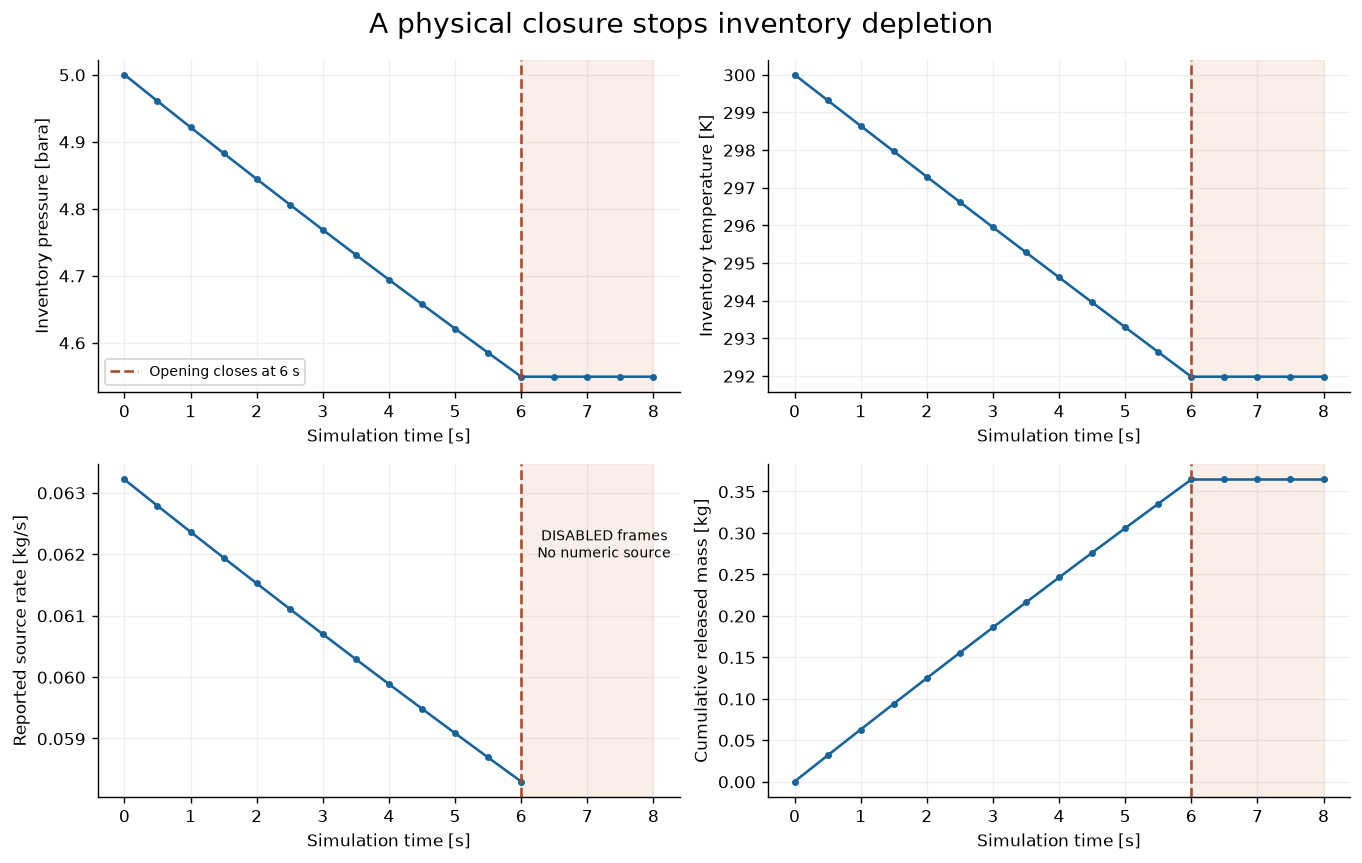

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
series = [
    (balances, "pressure_bara", "Inventory pressure [bara]"),
    (balances, "temperature_K", "Inventory temperature [K]"),
    (trajectory, "rate_kg_s", "Reported source rate [kg/s]"),
    (balances, "released_mass_kg", "Cumulative released mass [kg]"),
]
for ax, (table, column, label) in zip(axes.flat, series):
    ax.plot(table["time_s"], table[column], "o-", color="#17649b", markersize=3)
    ax.axvline(6.0, color="#ab4b2d", linestyle="--", label="Opening closes at 6 s")
    ax.axvspan(6.0, 8.0, color="#f7dfd3", alpha=0.5)
    ax.set(xlabel="Simulation time [s]", ylabel=label)
axes[0, 0].legend(fontsize=8)
axes[1, 0].text(
    0.87,
    0.72,
    "DISABLED frames\nNo numeric source",
    transform=axes[1, 0].transAxes,
    fontsize=8,
    ha="center",
)
fig.suptitle("A physical closure stops inventory depletion", fontsize=16)
fig.tight_layout()
plt.show()

In [15]:
container_rows = []
for use_model in [False, True]:
    unit, session = inventory_system("container-equivalence", use_model=use_model)
    session.runSteadyState()
    updated = session.step(0.5).get(0)
    record = balance_row(unit)
    record["container"] = "ProcessModel" if use_model else "ProcessSystem"
    record["frame_basis"] = parsed(updated)["provenance"]["releaseBasis"]
    container_rows.append(record)
assert (
    abs(container_rows[0]["released_mass_kg"] - container_rows[1]["released_mass_kg"]) < 1e-12
)

mixture_vessel = Inventory(
    "mixture",
    fluid({"nitrogen": 5.0 / 6.0, "methane": 1.0 / 6.0}),
    0.5,
    0.008,
    0.62,
    101325.0,
    HEM(),
    0.1,
)
mixture_vessel.runTransient(0.5, UUID.randomUUID())
mixture_balance = mixture_vessel.getBalance()
component_rows = []
for component in mixture_balance.getInitialComponentMassKg().keySet():
    initial = float(mixture_balance.getInitialComponentMassKg().get(component))
    remaining = float(mixture_balance.getRemainingComponentMassKg().get(component))
    released = float(mixture_balance.getReleasedComponentMassKg().get(component))
    residual = initial - remaining - released
    assert abs(residual) < 1e-7
    component_rows.append(
        {
            "Component": str(component),
            "Initial [kg]": initial,
            "Remaining [kg]": remaining,
            "Released [kg]": released,
            "Residual [kg]": residual,
        }
    )
display(
    pd.DataFrame(container_rows)[
        ["container", "released_mass_kg", "pressure_bara", "frame_basis"]
    ]
)
display(pd.DataFrame(component_rows).set_index("Component"))
checks["both_containers_and_HEM_component_conservation"] = True

,container,released_mass_kg,pressure_bara,frame_basis
0,ProcessSystem,0.031511,4.960524,COUPLED_RIGID_ADIABATIC_GAS_INVENTORY
1,ProcessModel,0.031511,4.960524,COUPLED_RIGID_ADIABATIC_GAS_INVENTORY


,Initial [kg],Remaining [kg],Released [kg],Residual [kg]
Component,,,,
methane,0.268286,0.266524,0.001761,3.816392e-17
nitrogen,2.342336,2.326959,0.015377,-3.590878e-16


### Disabling export is a different action

`session.setEnabled(source, False)` only disables reporting for that source. Its process unit can
still deplete. This short check makes the distinction observable. Never interpret a `DISABLED` frame
as a statement that all connected physical inventories are empty or that upstream isolation stopped
a leak.

In [16]:
export_vessel, export_session = inventory_system("export-only-disable")
export_session.runSteadyState()
export_session.setEnabled("opening", False)
export_disabled_frame = export_session.step(0.5).get(0)
assert str(export_disabled_frame.getStatus()) == "DISABLED"
assert export_vessel.getBalance().getReleasedMassKg() > 0.0
parsed(export_disabled_frame)
print("Export status:", export_disabled_frame.getStatus())
print(
    "Mass physically released while export was disabled [kg]:",
    export_vessel.getBalance().getReleasedMassKg(),
)
checks["export_disable_does_not_stop_physics"] = True

Export status: DISABLED
Mass physically released while export was disabled [kg]: 0.03151060189545048


## 9. Temporal validation: timestep refinement and an analytical blowdown limit

For a rigid, adiabatic, constant-$\gamma$ ideal gas during choked flow:

$$\frac{m(t)}{m_0}=\left[1+\frac{\gamma-1}{2}\frac{\dot m_0}{m_0}t\right]^{-2/(\gamma-1)}.$$

$$\frac{T(t)}{T_0}=\left(\frac{m(t)}{m_0}\right)^{\gamma-1},\qquad \frac{p(t)}{p_0}=\left(\frac{m(t)}{m_0}\right)^\gamma.$$

$m_0$, $T_0$, and $p_0$ are initial mass [kg], temperature [K], and absolute pressure [Pa];
$\dot m_0$ is the initial analytical release rate [kg/s], and $t$ time [s].
The reference uses initial NeqSim molar mass and heat-capacity ratio. NeqSim's inventory still uses
EOS properties and a VU flash, so exact equality with a calorically perfect gas is not expected.

For this benchmark, nitrogen starts at 2 bara and discharges to 0.1 bara, keeping the full 10 s
trajectory choked. The maximum internal substep controls explicit-Euler accuracy; the 1% inventory
withdrawal cap is a positivity bound, not an error estimate.

In [17]:
refinement_rows = []
for substep in [0.2, 0.1, 0.05]:
    reference_gas = fluid({"nitrogen": 1.0}, 300.0, 2.0)
    test_vessel = Inventory(
        "benchmark", reference_gas, 1.0, 0.01, 0.7, 10000.0, Ideal(), substep
    )
    initial = test_vessel.getFluid()
    initial.init(3)
    initial_mass = initial.getMass("kg")
    gamma = initial.getGamma()
    rate0 = ideal_reference(initial, 0.01, 0.7, 10000.0)
    fraction = (1.0 + (gamma - 1.0) * rate0 * 10.0 / (2.0 * initial_mass)) ** (
        -2.0 / (gamma - 1.0)
    )
    reference_pressure = 2e5 * fraction**gamma
    reference_temperature = 300.0 * fraction ** (gamma - 1.0)
    test_vessel.runTransient(10.0, UUID.randomUUID())
    state = test_vessel.getFluid()
    pressure_error = (state.getPressure("Pa") - reference_pressure) / 2e5
    temperature_error = (state.getTemperature() - reference_temperature) / 300.0
    mass_error = (state.getMass("kg") - initial_mass * fraction) / initial_mass
    assert max(abs(pressure_error), abs(temperature_error), abs(mass_error)) < 0.003
    refinement_rows.append(
        {
            "Max substep [s]": substep,
            "Final pressure [bara]": state.getPressure(),
            "Reference pressure [bara]": reference_pressure / 1e5,
            "Pressure error / initial [%]": pressure_error * 100,
            "Temperature error / initial [%]": temperature_error * 100,
            "Mass error / initial [%]": mass_error * 100,
            "Energy residual [J]": balance_row(test_vessel)["energy_residual_J"],
        }
    )
refinement = pd.DataFrame(refinement_rows)
pressure_values = refinement["Final pressure [bara]"].to_numpy()
change_ratio = abs(pressure_values[2] - pressure_values[1]) / abs(
    pressure_values[1] - pressure_values[0]
)
assert change_ratio < 0.6
checks["gas_blowdown_refinement_and_analytical_limit"] = True
display(refinement)
print("Successive pressure-change ratio (first-order expectation about 0.5):", change_ratio)

Successive pressure-change ratio (first-order expectation about 0.5): 0.4991081090027044


,Max substep [s],Final pressure [bara],Reference pressure [bara],Pressure error / initial [%],Temperature error / initial [%],Mass error / initial [%],Energy residual [J]
0,0.20,1.710613,1.711054,-0.022066,0.007676,-0.012774,-0.000057
1,0.10,1.710847,1.711054,-0.010338,0.013807,-0.006268,-0.000073
2,0.05,1.710965,1.711054,-0.004484,0.016866,-0.003020,-0.000224


## 10. Versioned exchange: JSON, NDJSON, CSV, coordinates, and validation

The complete JSON frame contains SI quantities, composition, model identity, diagnostics, sequence,
simulation time, UTC generation time, process UUIDs, and a fingerprint. CSV deliberately contains
only a reduced series; an empty CSV rate means **unavailable**, not zero. Archive full frames beside it.

The chosen spatial reference here is synthetic: origin at the example vessel centre projected onto
the deck; x east, y north, z up, positions in metres. The opening is at (2, 0, 1) and points east.
These coordinates are caller-supplied, never inferred from thermodynamics.

`verifyEnvelope` checks version and fingerprint. It does not perform JSON Schema validation; the
notebook runs both. The fingerprint detects content changes, not sender authenticity. Authenticated
transport and deployment controls belong to the application.

In [18]:
located_frames = [
    frame.withLocation(
        "synthetic-deck: origin=vessel-base; x=east,y=north,z=up",
        [2.0, 0.0, 1.0],
        [1.0, 0.0, 0.0],
    )
    for frame in inventory_frames
]
for frame in located_frames:
    parsed(frame)
ndjson_path = export_dir / "inventory-source-terms.ndjson"
ndjson_path.write_text("".join(str(frame.toNdjson()) for frame in located_frames))
csv_path = export_dir / "inventory-source-terms.csv"
csv_path.write_text(
    str(Frame.csvHeader()) + "".join(str(frame.toCsvRow()) for frame in located_frames)
)
first_payload = json.loads(str(located_frames[0].toJson()))
summary_payload = {
    key: first_payload[key]
    for key in [
        "schemaVersion",
        "scenarioId",
        "sourceId",
        "sequence",
        "simulationTime",
        "model",
        "location",
        "provenance",
    ]
}
display(Code(json.dumps(summary_payload, indent=2), language="json"))
display(pd.read_csv(csv_path).tail(6))
print(
    "Lossless NDJSON frames:", len(located_frames), "| Schema-validated and fingerprint-checked"
)

Lossless NDJSON frames: 17 | Schema-validated and fingerprint-checked


{
  "schemaVersion": "neqsim_safety_source_term.v1",
  "scenarioId": "coupled-gas-inventory",
  "sourceId": "opening",
  "sequence": 0,
  "simulationTime": {
    "unit": "s",
    "value": 0.0
  },
  "model": {
    "evidenceLevel": "UNQUALIFIED",
    "fluidModel": "SRK-EOS",
    "id": "ideal-gas-isentropic-orifice",
    "version": "1.0.0"
  },
  "location": {
    "direction": [
      1.0,
      0.0,
      0.0
    ],
    "position": [
      {
        "unit": "m",
        "value": 2.0
      },
      {
        "unit": "m",
        "value": 0.0
      },
      {
        "unit": "m",
        "value": 1.0
      }
    ],
    "referenceFrame": "synthetic-deck: origin=vessel-base; x=east,y=north,z=up"
  },
  "provenance": {
    "area": "process",
    "areaCalculationId": "037414f7-bb41-4c25-8b78-0f6d6c2f4d86",
    "cumulativeReleasedEnthalpyJ": "0.0",
    "cumulativeReleasedMassKg": "0.0",
    "equipment": "inventory",
    "equipmentCalculationId": "037414f7-bb41-4c25-8b78-0f6d6c2f4d86",
    "inventoryIntegrator": "EXPLICIT_EULER_VOLUME_INTERNAL_ENERGY_V1",
    "inventoryLastSubsteps": "0",
    "inventoryMaxSubstepS": "0.05",
    "inventoryTimeS": "0.0",
    "inventoryVolumeEnergySolves": "0",
    "inventoryVolumeM3": "1.0",
    "mode": "STEADY_STATE",
    "processType": "ProcessSystem",
    "rateTimeBasis": "INSTANTANEOUS_AT_FRAME_TIME",
    "releaseBasis": "COUPLED_RIGID_ADIABATIC_GAS_INVENTORY",
    "samplingPoint": "EQUIPMENT_FLUID"
  }
}

,scenarioId,sourceId,sequence,simulationTime_s,status,massFlowRate_kg_s
11,coupled-gas-inventory,opening,11,5.5,VALID,0.058691
12,coupled-gas-inventory,opening,12,6.0,VALID,0.058299
13,coupled-gas-inventory,opening,13,6.5,DISABLED,NaN
14,coupled-gas-inventory,opening,14,7.0,DISABLED,NaN
15,coupled-gas-inventory,opening,15,7.5,DISABLED,NaN
16,coupled-gas-inventory,opening,16,8.0,DISABLED,NaN


### A consistent boundary for another solver

For the zero-length opening, map `ORIFICE_EXIT` and conserve the exported integrated mass source.
The coefficient multiplies effective area: $A_\mathrm{eff}=C_dA$. Therefore:

$$\dot m=\rho u A_\mathrm{eff},\qquad \dot m_i=w_i\dot m,\qquad \dot E=\dot m\left(h+u^2/2\right)=\dot m h_0.$$

$\dot E$ is stagnation-energy flow [W] under the shared enthalpy convention, and $\dot m_i$ is
component mass flow [kg/s]. A boundary using inviscid velocity and the full physical area would
inject too much mass when $C_d<1$. A receiving CFD code may instead impose the integrated mass flux
on its own physical face area; document that mapping and avoid overconstraining pressure and velocity.

The contract's advective momentum is $\dot m u$ [N]; it excludes pressure thrust. A choked exit is
usually above ambient pressure. A pressure-resolving external solver can calculate subsequent
expansion and pressure forces. Do not add a guessed pressure-thrust term or treat the ambient-expanded
reference as a validated post-shock jet inlet. For two-phase input, total phase mass fractions are
available, but this v1 frame does not provide phase-specific species composition, droplet sizes, or
slip velocities. Use a compatible mixture boundary or request a richer assessed interface.

## 11. A standalone consumer with no NeqSim dependency

The following receiver imports only Python libraries and `jsonschema`. It verifies the Java writer's
fingerprint by preserving numeric tokens, validates the bundled schema, checks physical closure,
and maps the source into a generic boundary record. It enforces a single session's global sequence,
per-source time ordering, wall-clock age, accepted models, and diagnostic policy. Unknown warnings
require explicit review. `UNQUALIFIED` is rejected unless the teaching study opts in.

The producer's fingerprint uses its numeric spelling. Parsing to binary floats and serializing again
can change that spelling. The token-preserving verifier below is tested against all emitted frames;
retain original NDJSON bytes for cross-language transport and long-term replay.

In [19]:
%%writefile safety_source_term_results/source_term_consumer.py
"""Pure-Python reference receiver for NeqSim source-term v1; no JVM dependency."""

import hashlib
import json
import math
from datetime import datetime, timezone

from jsonschema import Draft202012Validator


class NumberToken(str):
    """Retain the producer's numeric spelling for its fingerprint contract."""


def unique_object(pairs):
    result = {}
    for key, value in pairs:
        if key in result:
            raise ValueError(f"Duplicate JSON key: {key}")
        result[key] = value
    return result


def canonical_tokens(value):
    if isinstance(value, NumberToken):
        return str(value)
    if isinstance(value, dict):
        parts = []
        for key in sorted(value, key=lambda text: text.encode("utf-16-be")):
            parts.append(canonical_tokens(key) + ":" + canonical_tokens(value[key]))
        return "{" + ",".join(parts) + "}"
    if isinstance(value, list):
        return "[" + ",".join(canonical_tokens(item) for item in value) + "]"
    encoded = json.dumps(value, ensure_ascii=False, separators=(",", ":"), allow_nan=False)
    return encoded.replace("\u2028", "\\u2028").replace("\u2029", "\\u2029")


def reject_constant(value):
    raise ValueError(f"Nonfinite JSON number: {value}")


def decode_verified(raw, schema):
    tokens = json.loads(
        raw,
        parse_float=NumberToken,
        parse_int=NumberToken,
        parse_constant=reject_constant,
        object_pairs_hook=unique_object,
    )
    fingerprint = tokens.pop("fingerprint")
    actual = hashlib.sha256(canonical_tokens(tokens).encode("utf-8")).hexdigest()
    if fingerprint != actual:
        raise ValueError("Fingerprint mismatch")
    frame = json.loads(raw, parse_constant=reject_constant, object_pairs_hook=unique_object)
    Draft202012Validator(schema).validate(frame)
    return frame


def quantity(value, unit):
    if value["unit"] != unit or not math.isfinite(value["value"]):
        raise ValueError(f"Expected finite {unit}")
    return float(value["value"])


def fractions(values):
    if any(not math.isfinite(value) or value < 0.0 for value in values.values()):
        raise ValueError("Invalid fraction")
    if not math.isclose(sum(values.values()), 1.0, rel_tol=0.0, abs_tol=1e-8):
        raise ValueError("Fractions do not sum to one")
    return values


class SourceTermReceiver:
    """One receiver per scenario/session; sequences are global across its sources."""

    def __init__(self, schema, scenario_id, *, allow_unqualified=False, max_age_s=30.0):
        self.schema = schema
        self.scenario_id = scenario_id
        self.allow_unqualified = allow_unqualified
        self.max_age_s = max_age_s
        self.next_sequence = 0
        self.last_times = {}
        self.allowed_models = {
            "ideal-gas-isentropic-orifice",
            "homogeneous-equilibrium-orifice",
        }
        self.allowed_diagnostics = {
            "MODEL_ASSUMPTIONS",
            "IDEAL_GAS_ASSUMPTIONS",
            "NO_PROPERTY_FALLBACK",
            "EXIT_ALIASES_THROAT",
            "ENTROPY_SOLVER",
            "NO_FORWARD_FLOW",
        }

    def accept(self, raw, *, now=None):
        frame = decode_verified(raw, self.schema)
        if frame["scenarioId"] != self.scenario_id:
            raise ValueError("Unexpected scenario")
        if frame["provenance"].get("sequenceMeaning") == "ENSEMBLE_CASE_INDEX":
            raise ValueError("Ensemble cases are not a live trajectory")
        if frame["sequence"] != self.next_sequence:
            raise ValueError("Duplicate, missing, or reordered session sequence")
        current = now or datetime.now(timezone.utc)
        created = datetime.fromisoformat(frame["generatedAt"].replace("Z", "+00:00"))
        age = (current - created).total_seconds()
        if age < -1.0 or age > self.max_age_s:
            raise ValueError("Frame age outside receiver policy")
        time_s = quantity(frame["simulationTime"], "s")
        previous = self.last_times.get(frame["sourceId"], -1.0)
        if time_s < previous:
            raise ValueError("Simulation time moved backwards")
        if frame["status"] not in {"VALID", "VALID_WITH_WARNINGS"}:
            self.next_sequence += 1
            self.last_times[frame["sourceId"]] = time_s
            return {"status": frame["status"], "time_s": time_s, "boundary": None}
        model = frame["model"]
        if model["evidenceLevel"] == "UNQUALIFIED" and not self.allow_unqualified:
            raise ValueError("Unqualified model requires explicit study acceptance")
        if model["id"] not in self.allowed_models or model["version"] != "1.0.0":
            raise ValueError("Model outside this receiver's assessed set")
        codes = {item["code"] for item in frame["diagnostics"]}
        if not codes.issubset(self.allowed_diagnostics):
            raise ValueError(
                f"Unreviewed diagnostics: {sorted(codes - self.allowed_diagnostics)}"
            )
        location = frame.get("location")
        if location is None:
            raise ValueError("Spatial boundary requires caller-supplied coordinates")
        direction = location["direction"]
        norm_squared = sum(value * value for value in direction)
        if not math.isfinite(norm_squared) or abs(norm_squared - 1.0) > 1e-8:
            raise ValueError("Source direction must be a finite unit vector")
        for coordinate in location["position"]:
            quantity(coordinate, "m")
        source = frame["source"]
        station = source["stations"]["ORIFICE_EXIT"]
        upstream = source["stations"]["UPSTREAM_STAGNATION"]
        rate = quantity(source["massFlowRate"], "kg/s")
        speed = quantity(station["velocity"], "m/s")
        density = quantity(station["density"], "kg/m3")
        area = quantity(source["effectiveArea"], "m2")
        enthalpy = quantity(station["specificEnthalpy"], "J/kg")
        stagnation = quantity(upstream["specificEnthalpy"], "J/kg")
        mass_fractions = fractions(station["componentMassFractions"])
        fractions(station["componentMoleFractions"])
        fractions(station["phaseMassFractions"])
        if not math.isclose(rate, density * speed * area, rel_tol=1e-7, abs_tol=1e-10):
            raise ValueError("Mass flux and effective-area closure failed")
        if not math.isclose(enthalpy + speed**2 / 2.0, stagnation, rel_tol=1e-7, abs_tol=1e-4):
            raise ValueError("Stagnation-energy closure failed")
        boundary = {
            "mass_rate_kg_s": rate,
            "component_rate_kg_s": {
                component: rate * value for component, value in mass_fractions.items()
            },
            "pressure_Pa_abs": quantity(station["pressure"], "Pa"),
            "temperature_K": quantity(station["temperature"], "K"),
            "velocity_m_s": speed,
            "effective_area_m2": area,
            "advective_momentum_N": rate * speed,
            "stagnation_energy_rate_W": rate * (enthalpy + speed**2 / 2.0),
            "phase_mass_fractions": station["phaseMassFractions"],
            "location": frame.get("location"),
        }
        self.next_sequence += 1
        self.last_times[frame["sourceId"]] = time_s
        return {"status": frame["status"], "time_s": time_s, "boundary": boundary}


if __name__ == "__main__":
    import argparse
    from pathlib import Path

    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("frames", type=Path)
    parser.add_argument("schema", type=Path)
    parser.add_argument("--replay-at", required=True)
    parser.add_argument("--allow-unqualified", action="store_true")
    args = parser.parse_args()
    lines = args.frames.read_text().splitlines()
    scenario = json.loads(lines[0])["scenarioId"]
    receiver = SourceTermReceiver(
        json.loads(args.schema.read_text()),
        scenario,
        allow_unqualified=args.allow_unqualified,
    )
    replay_time = datetime.fromisoformat(args.replay_at.replace("Z", "+00:00"))
    for line in lines:
        print(json.dumps(receiver.accept(line, now=replay_time), allow_nan=False))

Overwriting safety_source_term_results/source_term_consumer.py


In [20]:
consumer_path = export_dir / "source_term_consumer.py"
sys.path.insert(0, str(export_dir.resolve()))
from source_term_consumer import SourceTermReceiver, decode_verified

receiver = SourceTermReceiver(schema, "coupled-gas-inventory", allow_unqualified=True)
received = [receiver.accept(str(frame.toJson()), now=replay_now) for frame in located_frames]
assert all(record["boundary"] is None for record in received[-4:])
display(Code(json.dumps(received[0], indent=2), language="json"))
print("Accepted complete trajectory records:", len(received))

Accepted complete trajectory records: 17


{
  "status": "VALID",
  "time_s": 0.0,
  "boundary": {
    "mass_rate_kg_s": 0.06321395893029381,
    "component_rate_kg_s": {
      "nitrogen": 0.06321395893029381
    },
    "pressure_Pa_abs": 263410.0029837736,
    "temperature_K": 249.0965055818549,
    "velocity_m_s": 322.7210193560873,
    "effective_area_m2": 5.4977871437821384e-05,
    "advective_momentum_N": 20.400473263518258,
    "stagnation_energy_rate_W": 1692.9745336818378,
    "phase_mass_fractions": {
      "GAS": 1.0
    },
    "location": {
      "direction": [
        1.0,
        0.0,
        0.0
      ],
      "position": [
        {
          "unit": "m",
          "value": 2.0
        },
        {
          "unit": "m",
          "value": 0.0
        },
        {
          "unit": "m",
          "value": 1.0
        }
      ],
      "referenceFrame": "synthetic-deck: origin=vessel-base; x=east,y=north,z=up"
    }
  }
}

### Deliberate receiver failures

These are expected rejections caught and reported as test results. A schema-valid frame can still be
unacceptable to a specific consumer. For example, `UNQUALIFIED` is an evidence policy decision;
`STALE` is a native lifecycle result; an old `VALID` message can also fail the receiver's age policy.
A disabled or unavailable record remains visible with `boundary=None` and cannot be integrated as zero.

In [21]:
import copy

first_raw = str(located_frames[0].toJson())
rejections = []


def expect_rejection(name, operation):
    try:
        operation()
    except Exception as error:
        rejections.append(
            {"Test": name, "Outcome": "REJECTED", "Reason": str(error).splitlines()[0][:150]}
        )
    else:
        raise AssertionError("Expected rejection: " + name)


expect_rejection(
    "Unqualified evidence without opt-in",
    lambda: SourceTermReceiver(schema, "coupled-gas-inventory").accept(
        first_raw, now=replay_now
    ),
)
expect_rejection(
    "Old wall-clock message",
    lambda: SourceTermReceiver(schema, "coupled-gas-inventory", allow_unqualified=True).accept(
        first_raw,
        now=replay_now + timedelta(seconds=60),
    ),
)
sequence_receiver = SourceTermReceiver(schema, "coupled-gas-inventory", allow_unqualified=True)
sequence_receiver.accept(first_raw, now=replay_now)
expect_rejection(
    "Duplicate sequence", lambda: sequence_receiver.accept(first_raw, now=replay_now)
)
expect_rejection(
    "Missing sequence",
    lambda: SourceTermReceiver(schema, "coupled-gas-inventory", allow_unqualified=True).accept(
        str(located_frames[2].toJson()),
        now=replay_now,
    ),
)
tampered = first_raw.replace('"sequence":0', '"sequence":99')
expect_rejection("Changed payload", lambda: decode_verified(tampered, schema))
wrong_units = copy.deepcopy(first_payload)
wrong_units["source"]["massFlowRate"]["unit"] = "kg/hr"
expect_rejection("Wrong SI unit in schema", lambda: validator.validate(wrong_units))
failed_with_rate = copy.deepcopy(stale_data)
failed_with_rate["source"] = first_payload["source"]
expect_rejection(
    "STALE frame carrying an old source", lambda: validator.validate(failed_with_rate)
)
for raw in all_frames:
    decode_verified(raw, schema)
checks["standalone_fingerprint_schema_and_receiver_rejections"] = True
display(pd.DataFrame(rejections))

,Test,Outcome,Reason
0,Unqualified evidence without opt-in,REJECTED,Unqualified model requires explicit study acceptance
1,Old wall-clock message,REJECTED,Frame age outside receiver policy
2,Duplicate sequence,REJECTED,"Duplicate, missing, or reordered session sequence"
3,Missing sequence,REJECTED,"Duplicate, missing, or reordered session sequence"
4,Changed payload,REJECTED,Fingerprint mismatch
5,Wrong SI unit in schema,REJECTED,'kg/s' was expected
6,STALE frame carrying an old source,REJECTED,"{'calculationId': '4dc3799c-d2e0-46e0-bc1e-4e0c0125c84a', 'diagnostics': [{'code': 'PROCESS_STATE_STALE', 'message': 'Area not solved with expected ca"


## 12. Live delivery: native callbacks, HTTP, and a separate process

`subscribe` is synchronous. The callback below enqueues immutable frames in a bounded queue without
mutating the process. Queue overflow is an explicit delivery failure; the session counts it and its
returned batch remains available for caller-owned retry or durable storage. There is no hidden retry.

The HTTP example binds only to loopback and serves the already calculated immutable trajectory.
The request does not advance the process. A deployed producer would have one serialized process owner,
a bounded/durable output channel, an authenticated transport, and receiver timeout/deduplication rules.
NeqSim does not open network ports or provide a hard real-time deadline guarantee.

The `/v1/source-terms` route is an application adapter defined in this notebook, not a built-in
NeqSim HTTP service. In production use `Clock.systemUTC()` and actual receipt time. The fixed
clock and `--replay-at` parameter here explicitly label offline replay. Do not apply that replay
policy to a live operational stream.

In [22]:
from queue import Queue

callback_vessel, callback_session = inventory_system("callback-demo")
frame_queue = Queue(maxsize=4)


def on_frame(frame):
    frame_queue.put_nowait(str(frame.toNdjson()))


callback = jpype.JProxy("java.util.function.Consumer", dict(accept=on_frame))
callback_session.subscribe(callback)
callback_session.runSteadyState()
callback_session.step(0.5)
callback_session.unsubscribe(callback)
queued = []
while not frame_queue.empty():
    queued.append(decode_verified(frame_queue.get_nowait(), schema))
assert callback_session.getDeliveryFailureCount() == 0
print("Callback frames:", len(queued), "| sequences:", [item["sequence"] for item in queued])
checks["bounded_native_callback_delivery"] = True

Callback frames: 2 | sequences: [0, 1]


In [23]:
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer
from threading import Thread
from urllib.request import urlopen

wire_payload = ndjson_path.read_bytes()


class SourceEndpoint(BaseHTTPRequestHandler):
    def do_GET(self):
        if self.path != "/v1/source-terms":
            self.send_error(404)
            return
        self.send_response(200)
        self.send_header("Content-Type", "application/x-ndjson; charset=utf-8")
        self.send_header("Content-Length", str(len(wire_payload)))
        self.end_headers()
        self.wfile.write(wire_payload)

    def log_message(self, format_string, *arguments):
        return


server = ThreadingHTTPServer(("127.0.0.1", 0), SourceEndpoint)
server_thread = Thread(target=server.serve_forever, daemon=True)
server_thread.start()
try:
    endpoint = f"http://127.0.0.1:{server.server_port}/v1/source-terms"
    with urlopen(endpoint, timeout=5.0) as response:
        received_bytes = response.read()
        content_type = response.headers["Content-Type"]
    assert received_bytes == wire_payload
finally:
    server.shutdown()
    server.server_close()
    server_thread.join(timeout=5.0)
received_path = export_dir / "http-received.ndjson"
received_path.write_bytes(received_bytes)
external = subprocess.run(
    [
        sys.executable,
        str(consumer_path),
        str(received_path),
        str(export_dir / "safety-source-term.schema.json"),
        "--replay-at",
        "2026-09-21T12:00:00Z",
        "--allow-unqualified",
    ],
    check=True,
    capture_output=True,
    text=True,
)
assert not external.stderr, external.stderr
external_records = [json.loads(line) for line in external.stdout.splitlines()]
assert external_records == received
(export_dir / "external-boundaries.ndjson").write_text(external.stdout)
checks["HTTP_and_separate_process_round_trip"] = True
print("HTTP Content-Type:", content_type)
print("Separate-process records:", len(external_records))
print("The receiver used no NeqSim imports, Java classes, or shared process objects.")

HTTP Content-Type: application/x-ndjson; charset=utf-8
Separate-process records: 17
The receiver used no NeqSim imports, Java classes, or shared process objects.


### Downstream numerical use: component injection and released-mass reconstruction

The external program now has component mass-flow boundary conditions and an energy/momentum source.
Its saved records can drive a dispersion, CFD, ventilation, or other consequence solver with compatible
physics. This notebook demonstrates the input interface; it does not claim to run any proprietary
application or calculate consequence distances.

The following calculation uses only returned JSON to reconstruct emitted mass over **valid** intervals
up to the closure event. Trapezoidal integration of instantaneous snapshots is compared with native
integrated inventory accounting. We do not cross `DISABLED` intervals or apply a second withdrawal to
the NeqSim vessel. The exact closure time is supplied by this scenario, not inferred from a null rate.

In [24]:
valid_records = [record for record in external_records if record["boundary"] is not None]
time_values = np.array([record["time_s"] for record in valid_records])
rates = np.array([record["boundary"]["mass_rate_kg_s"] for record in valid_records])
reconstructed_mass = float(np.sum(np.diff(time_values) * (rates[:-1] + rates[1:]) / 2.0))
native_mass = float(balances.iloc[12]["released_mass_kg"])
relative_integration_error = reconstructed_mass / native_mass - 1.0
assert abs(relative_integration_error) < 0.005
component_input = pd.DataFrame(
    valid_records[0]["boundary"]["component_rate_kg_s"].items(),
    columns=["Component", "Injection [kg/s]"],
)
display(component_input)
display(
    pd.DataFrame(
        [
            {
                "Integrated receiver snapshots [kg]": reconstructed_mass,
                "Native released mass at closure [kg]": native_mass,
                "Difference [%]": relative_integration_error * 100,
            }
        ]
    )
)
checks["external_rate_integration_matches_inventory"] = True

,Component,Injection [kg/s]
0,nitrogen,0.063214


,Integrated receiver snapshots [kg],Native released mass at closure [kg],Difference [%]
0,0.364306,0.364427,-0.033278


## 13. Weighted uncertainty without hiding failed cases

A low/base/high coefficient set below uses illustrative probability weights 1:2:1. These values are
synthetic; a real study must justify distributions, correlations, and sample/tail convergence. When
uncertainty changes the upstream process state, first solve that complete process case and then build
its release request. `ReleaseFlowEnsemble` does not run the process for you.

P90 is a **90% non-exceedance** weighted empirical quantile, not a confidence bound or petroleum-reserve
exceedance convention. All case frames share one simulation time. Their sequence means alternative
case index, never consecutive transient time. Failed cases retain their original probability mass;
unconditional statistics are unavailable until every case is usable.

In [25]:
cases = ArrayList()
for name, coefficient, weight in [("low", 0.50, 1.0), ("base", 0.75, 2.0), ("high", 1.00, 1.0)]:
    cases.add(
        EnsembleCase(
            name,
            Request(gas, 0.01, coefficient, 101325.0),
            weight,
            java_map({"method": "synthetic joint scenarios; geometry and state fixed"}),
        )
    )
ensemble = Ensemble.evaluate("coefficient-study", HEM(), cases)
assert ensemble.isComplete()
ensemble_frames = list(
    ensemble.toFrames(
        "uncertainty-demo",
        "opening",
        UUID.fromString("00000000-0000-0000-0000-000000003861"),
        0.0,
        example_instant,
    )
)
ensemble_rows = []
for index, frame in enumerate(ensemble_frames):
    data = parsed(frame)
    ensemble_rows.append(
        {
            "Case": str(cases.get(index).getId()),
            "Probability [-]": float(ensemble.getProbabilities().get(index)),
            "Rate [kg/s]": value(data["source"]["massFlowRate"]),
            "Sequence meaning": data["provenance"]["sequenceMeaning"],
        }
    )
mean_rate = ensemble.getMeanMassFlowRateKgS()
p90_rate = ensemble.getMassFlowRateQuantileKgS(0.90)
weighted_reference = sum(row["Probability [-]"] * row["Rate [kg/s]"] for row in ensemble_rows)
assert abs(mean_rate - weighted_reference) < 1e-12
display(pd.DataFrame(ensemble_rows))
print("Unconditional mean [kg/s]:", mean_rate, "| P90 [kg/s]:", p90_rate)
expect_rejection(
    "Ensemble is not a time trajectory",
    lambda: SourceTermReceiver(schema, "uncertainty-demo", allow_unqualified=True).accept(
        str(ensemble_frames[0].toJson()),
        now=replay_now,
    ),
)
case_export = export_dir / "uncertainty-cases.ndjson"
case_export.write_text("".join(str(frame.toNdjson()) for frame in ensemble_frames))
print("Complete uncertainty frame file:", case_export)

Unconditional mean [kg/s]: 0.05023295789554377 | P90 [kg/s]: 0.06697727719405837
Complete uncertainty frame file: safety_source_term_results/uncertainty-cases.ndjson


,Case,Probability [-],Rate [kg/s],Sequence meaning
0,low,0.25,0.033489,ENSEMBLE_CASE_INDEX
1,base,0.50,0.050233,ENSEMBLE_CASE_INDEX
2,high,0.25,0.066977,ENSEMBLE_CASE_INDEX


Original usable probability: 0.25
Original unusable probability: 0.75
Native status counts: {VALID=1, VALID_WITH_WARNINGS=0, INVALID=0, UNSUPPORTED=1}


,Test,Outcome,Reason
7,Ensemble is not a time trajectory,REJECTED,Ensemble cases are not a live trajectory
8,Incomplete unconditional mean,REJECTED,java.lang.IllegalStateException: Incomplete ensemble: failed cases prohibit unconditional rate statistics
9,Incomplete unconditional P90,REJECTED,java.lang.IllegalStateException: Incomplete ensemble: failed cases prohibit unconditional rate statistics


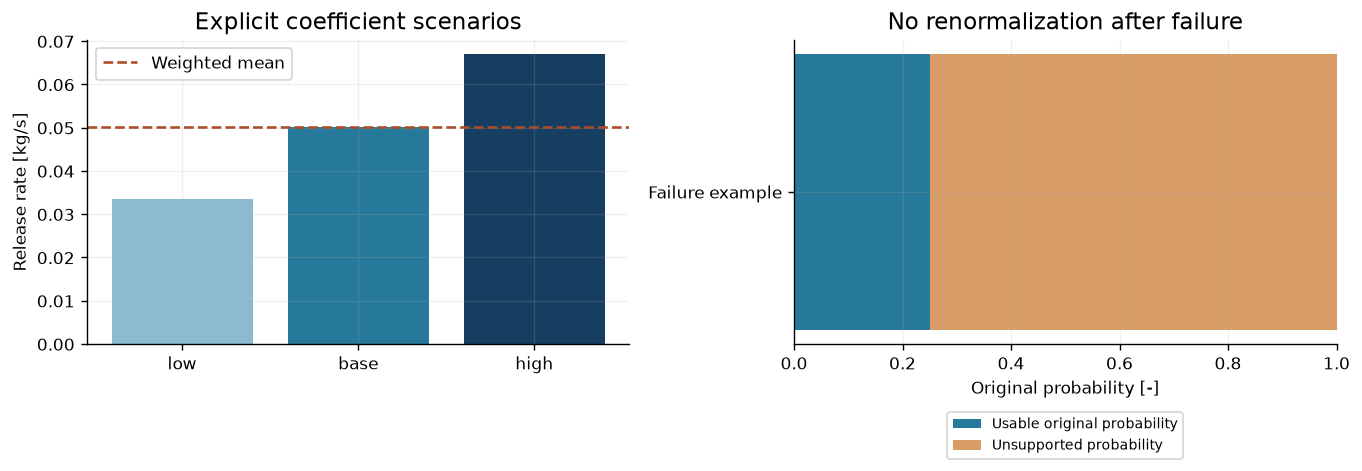

In [26]:
incomplete_cases = ArrayList()
incomplete_cases.add(cases.get(0))
incomplete_cases.add(
    EnsembleCase(
        "unsupported-cold-CO2",
        Request(fluid({"CO2": 1.0}, 210.0, 20.0), 0.01, 0.62, 1e5),
        3.0,
        java_map({"method": "deliberate applicability-failure example"}),
    )
)
incomplete = Ensemble.evaluate("failure-probability-demo", HEM(), incomplete_cases)
assert not incomplete.isComplete()
assert abs(incomplete.getUsableProbability() - 0.25) < 1e-12
expect_rejection("Incomplete unconditional mean", lambda: incomplete.getMeanMassFlowRateKgS())
expect_rejection(
    "Incomplete unconditional P90", lambda: incomplete.getMassFlowRateQuantileKgS(0.90)
)
failure_frames = list(
    incomplete.toFrames(
        "uncertainty-failure",
        "opening",
        UUID.fromString("00000000-0000-0000-0000-000000003862"),
        0.0,
        example_instant,
    )
)
for frame in failure_frames:
    parsed(frame)
print("Original usable probability:", incomplete.getUsableProbability())
print("Original unusable probability:", 1.0 - incomplete.getUsableProbability())
print("Native status counts:", str(incomplete.getStatusCounts()))
display(pd.DataFrame(rejections).tail(3))
checks["weighted_statistics_and_retained_failure_probability"] = True
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(
    [row["Case"] for row in ensemble_rows],
    [row["Rate [kg/s]"] for row in ensemble_rows],
    color=["#8bbbcf", "#26799a", "#153e60"],
)
axes[0].axhline(mean_rate, color="#ac4c26", linestyle="--", label="Weighted mean")
axes[0].set(ylabel="Release rate [kg/s]", title="Explicit coefficient scenarios")
axes[0].legend()
axes[1].barh(["Failure example"], [0.25], color="#26799a", label="Usable original probability")
axes[1].barh(
    ["Failure example"], [0.75], left=[0.25], color="#d89c66", label="Unsupported probability"
)
axes[1].set(
    xlim=(0, 1), xlabel="Original probability [-]", title="No renormalization after failure"
)
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=8)
fig.tight_layout()
plt.show()

## 14. Reusable handoff package, verification summary, and remaining scope

The ZIP below contains the original frames, bundled schema, reduced CSV, standalone receiver,
externally derived boundary records, numerical tables, and the exact runtime manifest. It can be
shared with a developer building an adapter in Python, Java, C++, C#, or another language.

| Integration decision | Required choice |
|---|---|
| Process ownership | One serialized owner; solve before capture, or let the session run/step |
| Release basis | Hypothetical opening or coupled gas inventory; never subtract the same loss twice |
| Physics | Explicit model, validity range, property basis, and review of diagnostics |
| Boundary station | Orifice/throat versus ideal expanded reference; mass, energy and momentum mapping |
| Spatial data | Caller-supplied frame, origin, axes, position, direction and actual geometry |
| Time | Simulation seconds plus wall-clock age; global session sequence and per-source history |
| Lifecycle | No numeric reuse on invalid/stale/unsupported/disabled intervals |
| Delivery | Bounded queues, visible failures, application retries and deduplication |
| Evidence | UNQUALIFIED remains visible; software success does not elevate model evidence |
| External consequence model | Weather, terrain, obstacles, entrainment, dispersion, ignition and effects |

**Native boundaries still tracked by [#3860](https://github.com/equinor/neqsim/issues/3860):**
multiphase/phase-selective transient inventories, receiving-pressure event location, long-pipe/full-bore
rupture, non-equilibrium discharge, mixture-specific solids, unresolved flashing mixtures, and independent
experimental qualification. This executed tutorial addresses the demonstration deliverable; it does
not satisfy all remaining issue acceptance criteria.

A native transient failure is transactional within `ReleaseInventory`, but other process units or
clocks may already have advanced. Restore the complete process before resuming; a steady run alone
is not dynamic rollback. Detect phase changes and pressure-boundary crossings, then reduce timestep
or use an assessed model for that regime.

In [27]:
benchmark.to_csv(export_dir / "dilute-gas-reference.csv", index=False)
refinement.to_csv(export_dir / "inventory-timestep-refinement.csv", index=False)
balances.to_csv(export_dir / "inventory-balances.csv", index=False)
(export_dir / "all-validated-frames.ndjson").write_text("\n".join(all_frames) + "\n")
for raw in all_frames:
    validator.validate(json.loads(raw))
    decode_verified(raw, schema)
manifest = {
    "runtime": provenance,
    "validation": checks,
    "validated_frame_count": len(all_frames),
    "expected_rejection_count": len(rejections),
    "engineering_evidence": "Analytical-limit, conservation and interface tests; UNQUALIFIED",
    "clock_basis": (
        "Fixed teaching/replay clock; production uses Clock.systemUTC() "
        "and actual receipt time"
    ),
    "tracked_issue": "https://github.com/equinor/neqsim/issues/3860",
}
(export_dir / "run-manifest.json").write_text(json.dumps(manifest, indent=2))
archive_path = Path(shutil.make_archive("neqsim_safety_source_terms", "zip", export_dir))
assert all(checks.values())
display(pd.DataFrame(checks.items(), columns=["Validation", "Passed"]))
print("Schema/fingerprint-validated frames:", len(all_frames))
print("Expected rejected requests/corruptions:", len(rejections))
print("Reusable package:", archive_path.resolve(), "| bytes:", archive_path.stat().st_size)

Schema/fingerprint-validated frames: 64
Expected rejected requests/corruptions: 10
Reusable package: /workspace/scratch/14968d4bce5d/neqsim_safety_source_terms.zip | bytes: 51835


,Validation,Passed
0,station_energy_entropy_phase_closure,True
1,dilute_gas_reference_within_1_5_percent,True
2,unavailable_rates_not_zero_filled,True
3,steady_process_mass_balance,True
4,stale_capture_omits_numeric_payload,True
5,process_model_composition_and_identity,True
6,native_separator_dynamics_reach_frames,True
7,coupled_inventory_mass_energy_and_closure_event,True
8,both_containers_and_HEM_component_conservation,True
9,export_disable_does_not_stop_physics,True


### Interpretation and exercises

The dilute-gas sweep checks the choking transition against an independently written equation.
The gas-inventory case cools and depressurizes as mass is released, conserves component mass and
energy, and stops depletion when the actual opening closes. Halving the internal substep reduces
the pressure change between successive solutions. The external consumer reproduces the same source
records without sharing a JVM, and its integrated rate agrees with the native balance within the
stated temporal tolerance. Unsupported probability remains visible in an incomplete ensemble.

1. Repeat the gas trajectory with half the output interval and half the internal substep. Compare
   native released mass, reconstructed mass, and temperature minima.
2. Add a second area and source to a `ProcessModel`; consume the complete global session sequence.
3. Replace the nitrogen gas with an assessed mixture and HEM. Inspect every phase and diagnostic,
   and stop if the inventory leaves its gas-only regime.
4. Implement a receiver in another language using the bundled schema and original NDJSON fixtures.
5. Connect the boundary records to an independently validated consequence model with explicitly
   supplied location, weather and geometry. Record its separate model/version and validation basis.

### Primary source references

All implementation references below are pinned to the source used for the retained run:

- [Issue #3860 and remaining acceptance criteria](https://github.com/equinor/neqsim/issues/3860)
- [Release models, equations and applicability](https://github.com/equinor/neqsim/blob/e4e9f27534870f510203512f912dd3aa2b9cde1d/docs/process/safety/release-flow-models.md)
- [Neutral source-term contract](https://github.com/equinor/neqsim/blob/e4e9f27534870f510203512f912dd3aa2b9cde1d/docs/process/safety/source-term-contract.md)
- [Live process sessions and failure semantics](https://github.com/equinor/neqsim/blob/e4e9f27534870f510203512f912dd3aa2b9cde1d/docs/process/safety/live-source-term-sessions.md)
- [Coupled gas inventory and temporal validation](https://github.com/equinor/neqsim/blob/e4e9f27534870f510203512f912dd3aa2b9cde1d/docs/process/safety/coupled-release-inventory.md)
- [Weighted uncertainty and benchmark matrix](https://github.com/equinor/neqsim/blob/e4e9f27534870f510203512f912dd3aa2b9cde1d/docs/process/safety/source-term-uncertainty.md)
- [Java source and focused regression tests](https://github.com/equinor/neqsim/tree/e4e9f27534870f510203512f912dd3aa2b9cde1d/src/test/java/neqsim/process/safety/release)

**Documentation impact:** this notebook documents the existing Java APIs and consumer responsibilities;
no core model, schema or qualification level is changed. The repository README, examples catalog,
and a dedicated validation-ledger shard accompany it.